# Battery Data Preparation — Cyclic Feature Extraction

This notebook preprocesses the raw battery cycling data into per-cycle summary features for use in the lifetime prediction models. It is the first notebook to run in this project.

For each battery and each cycle, it extracts four key measurements:
1. **Charge Capacity** — normalized to the first cycle (SOH proxy)
2. **Temperature** — mean per cycle
3. **Internal Resistance** — max per cycle
4. **CycleTime** — duration of each cycle in minutes (derived from DateTime)

A custom spike-removal filter (`strong_low_pass_filter`) is applied to suppress measurement artifacts without smoothing genuine degradation trends. The schedule version (charging protocol version) is also extracted and appended as a categorical feature.

The processed data is saved as compressed pickle files for use in the modeling notebooks.

**Pipeline overview:**
1. Load raw data file paths
2. Extract per-cycle features for all batteries
3. Plot raw features for visual inspection
4. Rename DateTime to CycleTime
5. Extract schedule version information
6. Save raw feature DataFrames to disk
7. Compute target variable (cycles to SOH threshold)
8. Apply spike-removal filter
9. Plot filtered vs raw data for quality check
10. Save filtered feature DataFrames to disk

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
import numpy as np
import os
import seaborn as sns

import gzip
import pickle

os.chdir('../')
from functions.model_wrapper import Tree_Model, rfm_params, xgboost_params

In [2]:
from functions.dataprep import group_values, replace_DateTime_CycleTime, strong_low_pass_filter, plot_Current, strong_low_pass_filter
from functions.model_wrapper import get_y_w_threshold

## 1. Load raw data file paths

Collects all battery data file paths from the raw data directory, excluding metadata files.

In [3]:
data_dir = 'data/raw_data/'
data_files = [file for file in os.listdir(data_dir) if 'Meta' not in file 
              and 'sdu' not in file 
              and 'jena' not in file
              and 'png' not in file
              and 'pckl' not in file
             and '.DS_Store' not in file
             and 'CH' in file]
data_files

['2017-06-30_4_4C-55per_6C_CH19.csv',
 '2018-04-12_batch8_CH38.csv',
 '2018-04-12_batch8_CH10.csv',
 '2017-05-12_7C-30per_3_6C_CH39.csv',
 '2017-06-30_3_6C-80per_3_6C_CH1.csv',
 '2017-06-30_4_4C-47per_5_5C_CH18.csv',
 '2018-04-12_batch8_CH11.csv',
 '2018-04-12_batch8_CH39.csv',
 '2017-05-12_8C-35per_3_6C_CH48.csv',
 '2017-06-30_4_8C-80per_4_8C_CH4.csv',
 '2017-06-30_6C-31per_4_25C_CH44.csv',
 '2017-06-30_4_9C-69per_4_25C_CH26.csv',
 '2018-04-12_batch8_CH13.csv',
 '2017-05-12_5_4C-50per_3C_CH14.csv',
 '2017-06-30_3_6C-80per_3_6C_CH3.csv',
 '2017-06-30_3_6C-80per_3_6C_CH2.csv',
 '2017-05-12_5_4C-60per_3_6C_CH23.csv',
 '2018-04-12_batch8_CH12.csv',
 '2017-06-30_4_8C-80per_4_8C_CH7.csv',
 '2018-04-12_batch8_CH16.csv',
 '2017-06-30_4_4C-24per_5C_CH17.csv',
 '2018-04-12_batch8_CH17.csv',
 '2017-05-12_5_4C-70per_3C_CH18.csv',
 '2017-05-12_6C-60per_3C_CH30.csv',
 '2018-04-12_batch8_CH15.csv',
 '2018-04-12_batch8_CH29.csv',
 '2018-04-12_batch8_CH8.csv',
 '2017-06-30_4_65C-69per_6C_CH23.csv',
 '

## 2. Extract per-cycle features

For each battery file, loads the raw data and computes per-cycle aggregates for Charge Capacity (max), Temperature (mean), Internal Resistance (max), and DateTime (min, converted to cycle duration). The Charge Capacity is normalized to the first cycle so all batteries start at 1.0.

In [26]:
columns = ["Charge_Capacity", "Temperature", "Internal_Resistance", "DateTime"][:]
hows = ["max", "mean", "max", "min"][:]
data_frames = []  
for i, column in enumerate(columns[::]):
    df_col =  pd.DataFrame()
    print(column)
    for data_file in data_files[::]:
        df_file = pd.DataFrame()  
        df_file = pd.read_csv(f'data/raw_data/{data_file}')
        df_file = df_file[df_file['Cycle_Index'] >= 2]
        # plot_CV(df_file)
        df_col = pd.concat([df_col, group_values(df_file.loc[1:,:], column, hows[i], data_file[:-4])], axis = 1)  # discard first row (first cycle)

    # print(df_col.shape)
    index_suffix = df_col.index[0].split('_')[1:]
    index_suffix = "_".join(index_suffix)
    # print(index_suffix)
    new_indices = [f'{str(i).zfill(2)}_{index_suffix}' for i in np.arange(1, df_col.shape[0]+1)]
    # print(new_indices[::-1])
    df_col.index = new_indices
    
    data_frames.append(df_col)
data_frames[0].head(40)


Charge_Capacity
Temperature
Internal_Resistance
DateTime


,2017-06-30_4_4C-55per_6C_CH19,2018-04-12_batch8_CH38,2018-04-12_batch8_CH10,2017-05-12_7C-30per_3_6C_CH39,2017-06-30_3_6C-80per_3_6C_CH1,2017-06-30_4_4C-47per_5_5C_CH18,2018-04-12_batch8_CH11,2018-04-12_batch8_CH39,2017-05-12_8C-35per_3_6C_CH48,2017-06-30_4_8C-80per_4_8C_CH4,...,2018-04-12_batch8_CH34,2017-06-30_5_2C-66per_3_5C_CH35,2018-04-12_batch8_CH1,2018-04-12_batch8_CH20,2017-05-12_6C-40per_3C_CH25,2017-05-12_7C-40per_3_6C_CH41,2018-04-12_batch8_CH21,2018-04-12_batch8_CH35,2017-06-30_4_8C-80per_4_8C_CH8,2017-05-12_6C-40per_3_6C_CH34
01_Charge_Capacity,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
02_Charge_Capacity,0.999469,1.000355,1.000607,1.000993,0.999561,1.000822,1.001084,1.000842,1.001160,1.001077,...,1.000676,1.001631,0.998316,1.000718,1.000789,1.001021,1.000793,1.000817,1.002038,1.000945
03_Charge_Capacity,1.000710,1.000647,1.001124,1.001488,1.000024,1.001965,1.001746,1.001472,1.001798,1.001585,...,1.001647,1.002699,1.001499,1.001188,1.001469,1.001249,1.001366,1.001465,1.003053,1.001430
04_Charge_Capacity,1.001153,1.000878,1.001623,1.001663,1.000403,1.001601,1.002326,1.002019,1.002177,1.002998,...,1.002058,1.003495,1.001780,1.001666,1.001844,1.001563,1.001734,1.001803,1.003054,1.001770
05_Charge_Capacity,1.000947,1.000875,1.001856,1.001903,1.000303,1.002199,1.002544,1.002555,1.002502,1.002628,...,1.002594,1.003831,1.002124,1.001897,1.002313,1.001953,1.002036,1.002170,1.003826,1.001987
06_Charge_Capacity,1.001061,1.000858,1.002276,1.002134,0.999825,1.002818,1.002960,1.002934,1.002711,1.002640,...,1.002980,1.004219,1.001083,1.002236,1.002503,1.002248,1.002051,1.002625,1.004159,1.002229
07_Charge_Capacity,1.001048,1.000857,1.002395,1.002336,1.000283,1.001961,1.003235,1.003239,1.002870,1.002884,...,1.003381,1.004135,1.002594,1.002389,1.002664,1.002405,1.002263,1.002845,1.003788,1.002341
08_Charge_Capacity,1.000631,1.000757,1.002756,1.001566,1.000705,1.002601,1.003442,1.003401,1.003017,1.002790,...,1.003685,1.004551,1.002678,1.002673,1.002833,1.002483,1.002459,1.003059,1.004376,1.002304
09_Charge_Capacity,1.000738,1.000705,1.002865,1.002752,0.999735,1.002954,1.003474,1.003504,1.003085,1.002914,...,1.003856,1.004749,1.002801,1.002791,1.002896,1.002725,1.002619,1.003236,1.004534,1.002707
10_Charge_Capacity,1.000275,1.000661,1.002884,1.002850,0.999578,1.002043,1.003456,1.003775,1.003142,1.003092,...,1.003973,1.004710,1.001527,1.002790,1.003171,1.002760,1.002509,1.003206,1.004396,1.002804


## 3. Plot raw features for visual inspection

Each feature is plotted across all cycles and all batteries to check for obvious artifacts or anomalies before filtering.

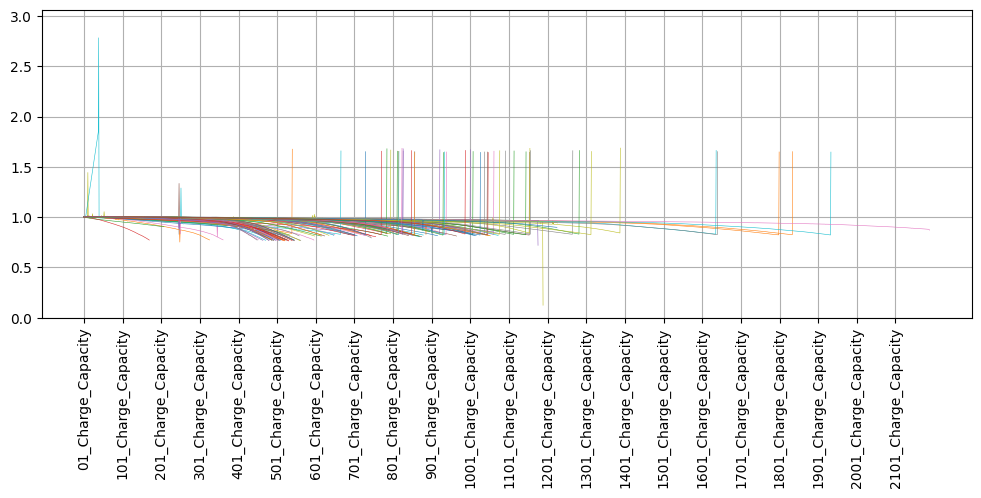

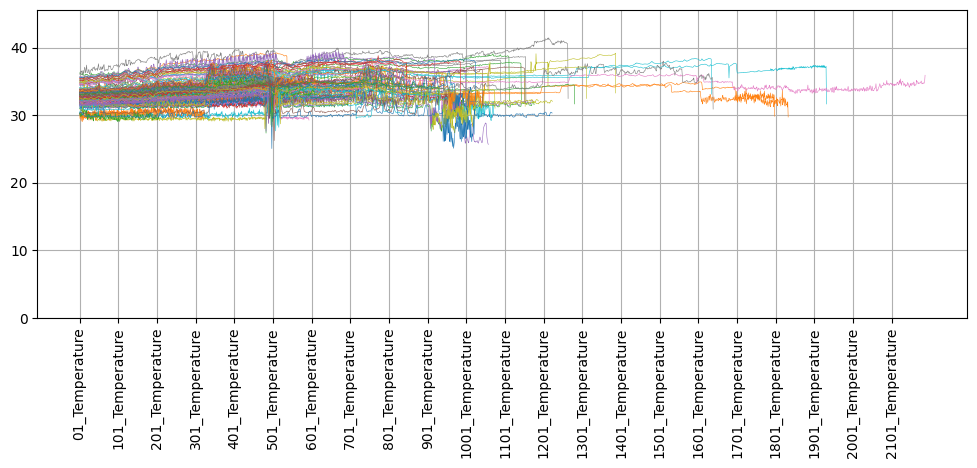

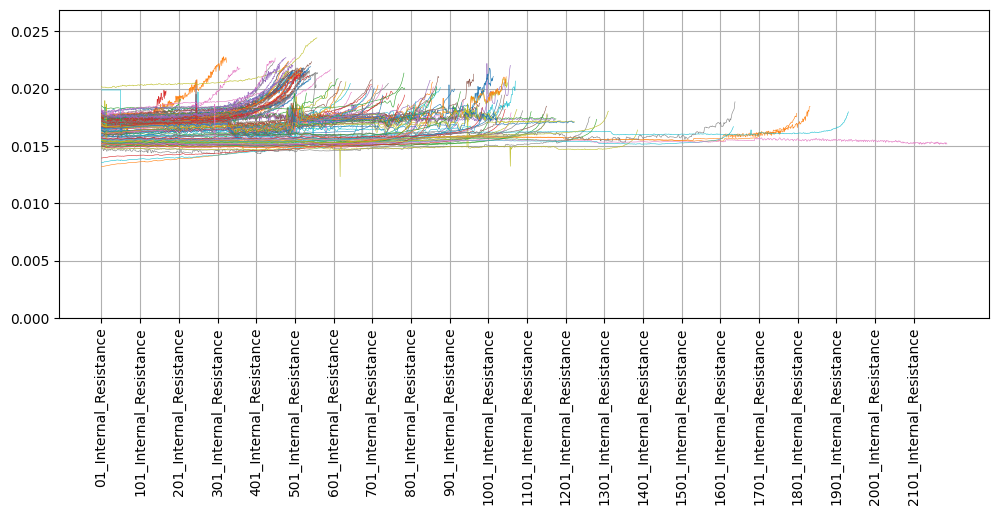

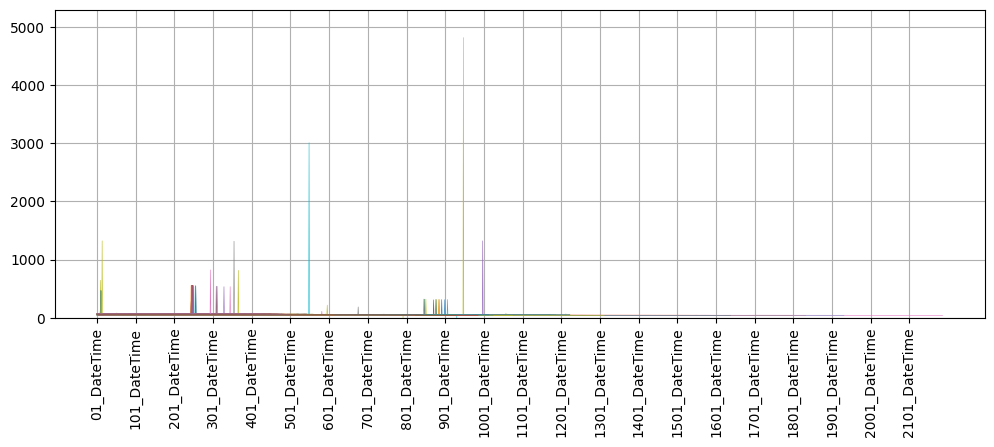

In [32]:
for i in range(4):
    plt.figure(figsize = (12,4))
    plt.plot(data_frames[i], linewidth = 0.4)
    plt.xticks(np.arange(0,data_frames[i].shape[0]+10,100), rotation = 90)
    y_max = data_frames[i].max().max()
    y_min = data_frames[i].min().min()
    plt.ylim(y_min - y_min/np.abs(y_min)*(np.abs(y_min)*0.1), 
             y_max*1.1)
    plt.ylim(y_max*0.0, y_max*1.1)
    plt.grid()
    plt.show()

## 4. Rename DateTime to CycleTime

The DateTime feature is renamed to CycleTime throughout, since after differencing it represents cycle duration (not an absolute timestamp). This avoids confusion with the raw DateTime column.

In [33]:
data_frames = replace_DateTime_CycleTime(data_frames)

In [34]:
data_frames[0]
df_col

,2017-06-30_4_4C-55per_6C_CH19,2018-04-12_batch8_CH38,2018-04-12_batch8_CH10,2017-05-12_7C-30per_3_6C_CH39,2017-06-30_3_6C-80per_3_6C_CH1,2017-06-30_4_4C-47per_5_5C_CH18,2018-04-12_batch8_CH11,2018-04-12_batch8_CH39,2017-05-12_8C-35per_3_6C_CH48,2017-06-30_4_8C-80per_4_8C_CH4,...,2018-04-12_batch8_CH34,2017-06-30_5_2C-66per_3_5C_CH35,2018-04-12_batch8_CH1,2018-04-12_batch8_CH20,2017-05-12_6C-40per_3C_CH25,2017-05-12_7C-40per_3_6C_CH41,2018-04-12_batch8_CH21,2018-04-12_batch8_CH35,2017-06-30_4_8C-80per_4_8C_CH8,2017-05-12_6C-40per_3_6C_CH34
01_CycleTime,60.234717,46.734225,46.809720,51.962598,49.102567,60.082020,46.601897,48.260130,51.079440,60.026277,...,45.472168,60.030882,48.224428,48.245272,53.057615,51.142162,48.868252,46.879020,60.026010,51.713052
02_CycleTime,60.199997,46.826430,46.730108,51.960435,51.952107,60.059727,46.369873,48.164113,51.040740,60.026195,...,45.534218,60.030278,48.230387,48.174862,53.057040,51.143778,48.875232,46.820542,60.025825,51.713305
03_CycleTime,60.177747,46.750525,46.513703,51.958372,51.088930,60.060672,46.230413,48.227145,50.972637,60.025632,...,45.721082,60.030452,48.115370,48.249315,53.056925,51.143012,48.713922,46.719068,60.026748,51.713623
04_CycleTime,60.200950,46.782938,46.456178,51.958275,50.065628,60.074032,46.243718,48.372337,51.057763,60.025863,...,45.815387,60.030442,48.135043,48.271277,53.055605,51.144653,48.713508,46.809675,60.025837,51.713823
05_CycleTime,60.193797,46.766320,46.384442,51.958412,51.944088,60.058217,46.262755,48.307290,51.119130,60.025977,...,45.787027,60.030193,48.103817,48.224288,53.057482,51.141585,48.522708,46.893385,60.026500,51.713250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183_CycleTime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2184_CycleTime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2185_CycleTime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2186_CycleTime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Extract schedule version

The charging protocol version ('7.00.08' or '7.00.13') is extracted from the metadata file for each battery and appended as an additional feature. The two groups differ in cycle time and have measurably different lifetime distributions.

In [35]:
schedule_versions = []
indices = []
for data_file in data_files:
    data_file_prefix = data_file.split('.')[0]
    indices.append(data_file_prefix)
    meta_data_file = data_file_prefix + '_Metadata.csv'
    schedule_versions.append(pd.read_csv(data_dir+meta_data_file)["schedule_version"].values[0][-7:])
df_schedule_version = pd.DataFrame(data = schedule_versions,
                                   columns = ['schedule_version'],
                                   index= indices
                                   ).T
df_schedule_version

,2017-06-30_4_4C-55per_6C_CH19,2018-04-12_batch8_CH38,2018-04-12_batch8_CH10,2017-05-12_7C-30per_3_6C_CH39,2017-06-30_3_6C-80per_3_6C_CH1,2017-06-30_4_4C-47per_5_5C_CH18,2018-04-12_batch8_CH11,2018-04-12_batch8_CH39,2017-05-12_8C-35per_3_6C_CH48,2017-06-30_4_8C-80per_4_8C_CH4,...,2018-04-12_batch8_CH34,2017-06-30_5_2C-66per_3_5C_CH35,2018-04-12_batch8_CH1,2018-04-12_batch8_CH20,2017-05-12_6C-40per_3C_CH25,2017-05-12_7C-40per_3_6C_CH41,2018-04-12_batch8_CH21,2018-04-12_batch8_CH35,2017-06-30_4_8C-80per_4_8C_CH8,2017-05-12_6C-40per_3_6C_CH34
schedule_version,7.00.08,7.00.13,7.00.13,7.00.08,7.00.08,7.00.08,7.00.13,7.00.13,7.00.08,7.00.08,...,7.00.13,7.00.08,7.00.13,7.00.13,7.00.08,7.00.08,7.00.13,7.00.13,7.00.08,7.00.08


In [36]:
data_frames.append(df_schedule_version)

## 6. Save raw feature DataFrames to disk

In [37]:
with gzip.open('data/data_frames_renum.pckl', 'wb') as f:
    pickle.dump(data_frames, f)

In [4]:
with gzip.open('data/data_frames_renum.pckl', 'rb') as f:
    data_frames = pickle.load(f)

## 7. Compute target variable

The target variable is the number of cycles before each battery's charge capacity drops below 90% of its initial value (SOH threshold = 0.9).

In [24]:
# get y which is number of cycle it dropped below threshold
threshold = 0.9
y_all = get_y_w_threshold(data_frames[0], threshold)

In [26]:
y_all

2017-06-30_4_4C-55per_6C_CH19     411
2018-04-12_batch8_CH38            422
2018-04-12_batch8_CH10            937
2017-05-12_7C-30per_3_6C_CH39     668
2017-06-30_3_6C-80per_3_6C_CH1    540
                                 ... 
2017-05-12_7C-40per_3_6C_CH41     549
2018-04-12_batch8_CH21            855
2018-04-12_batch8_CH35            920
2017-06-30_4_8C-80per_4_8C_CH8    411
2017-05-12_6C-40per_3_6C_CH34     748
Length: 136, dtype: int64

## 8. Apply spike-removal filter

`strong_low_pass_filter` replaces any data point that differs from the previous one by more than a threshold (fractional change) with the previous value. This suppresses measurement spikes — common in battery cycling data — without distorting genuine degradation trends.

In [8]:
filtered_data_frames = []
for data_frame in data_frames:
    if data_frame.shape[0] > 1:
        filtered_data_frames.append(strong_low_pass_filter(data_frame.copy(), filter_value = 0.01))
    else:
        filtered_data_frames.append(data_frame)

Processing Charge_Capacity
Processing Temperature
Processing Internal_Resistance
Processing CycleTime


In [16]:
y_all = get_y_w_threshold(filtered_data_frames[0], 0.9)

## 9. Plot filtered vs raw data for quality check

Filtered and raw data are plotted side by side to confirm the filter removed spikes without over-smoothing the signal.

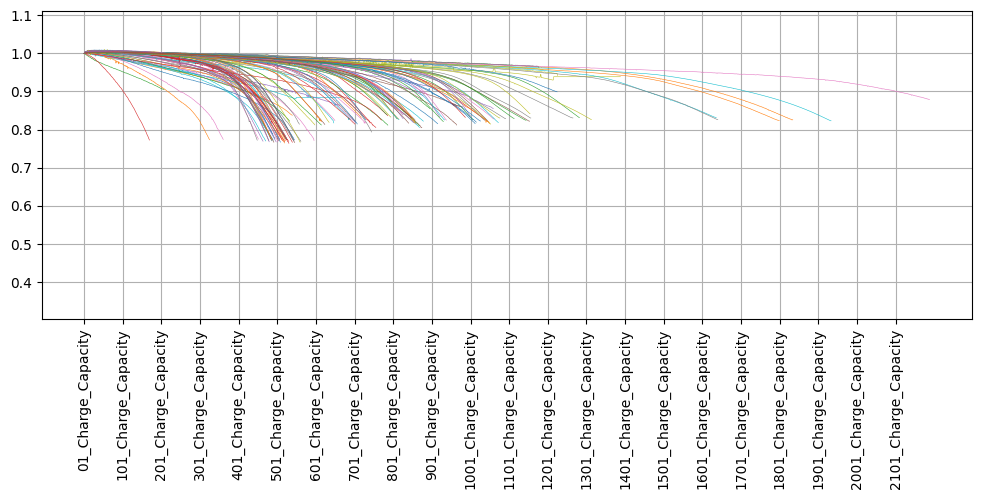

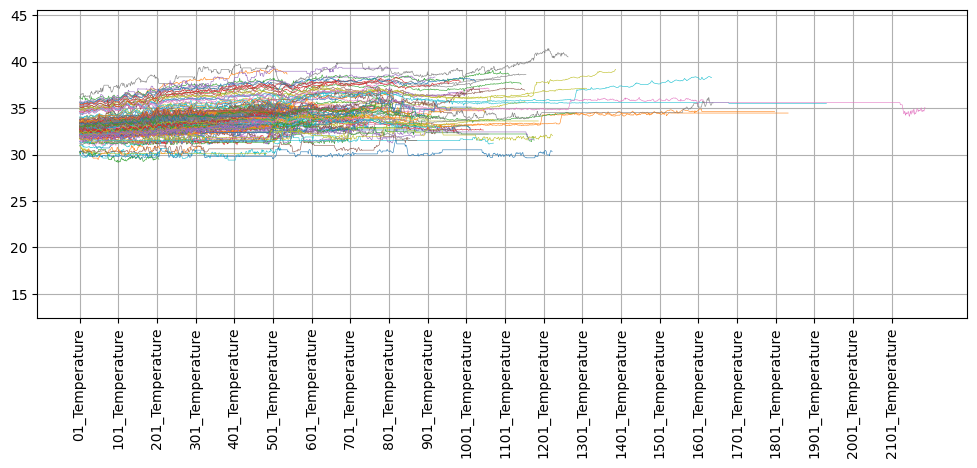

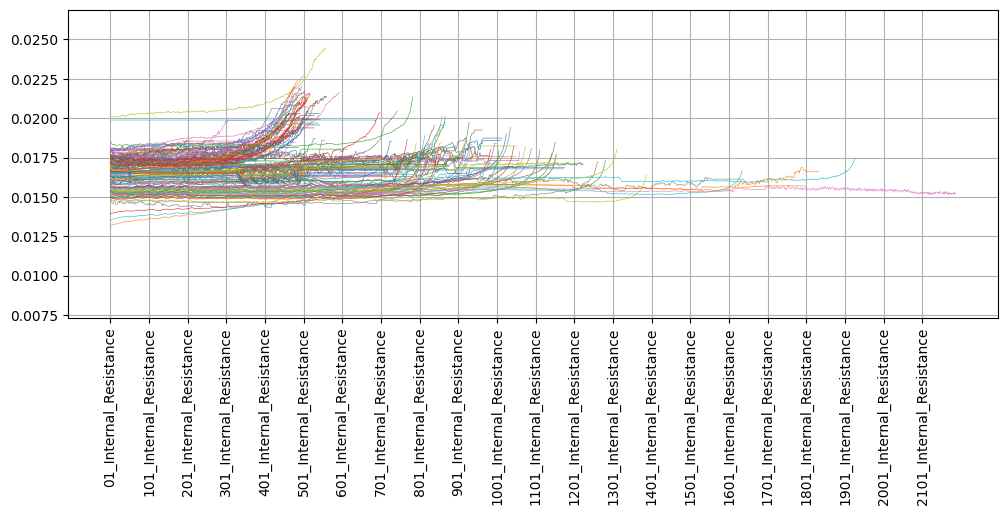

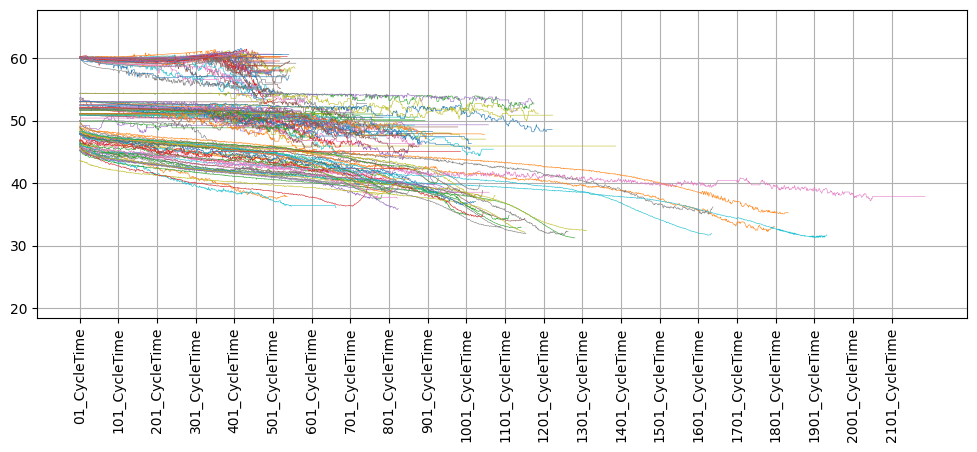

In [17]:
for i in range(4):
    plt.figure(figsize = (12,4))
    plt.plot(filtered_data_frames[i], linewidth = 0.4)
    plt.xticks(np.arange(0, filtered_data_frames[i].shape[0]+10,100), rotation = 90)
    y_max = filtered_data_frames[i].max().max()
    y_min = filtered_data_frames[i].min().min()
    plt.ylim(y_max*0.3, y_max*1.1)
    plt.grid()
    plt.show()

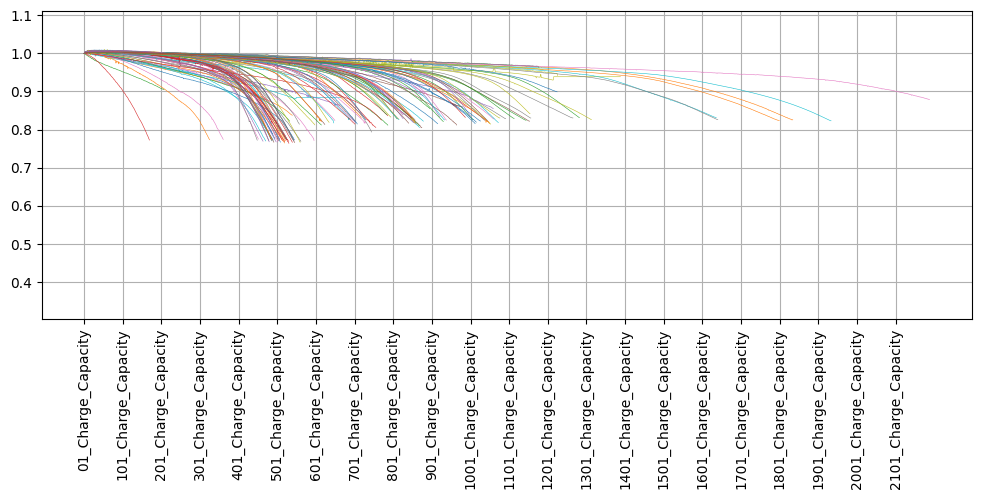

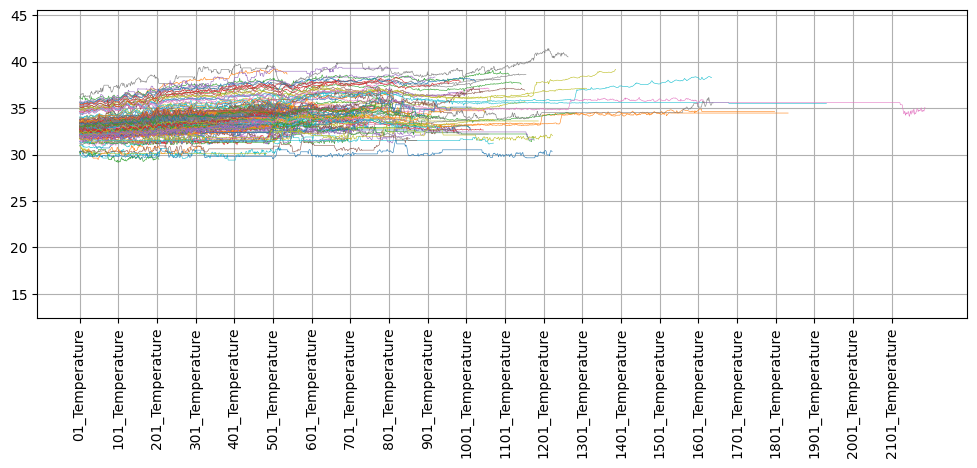

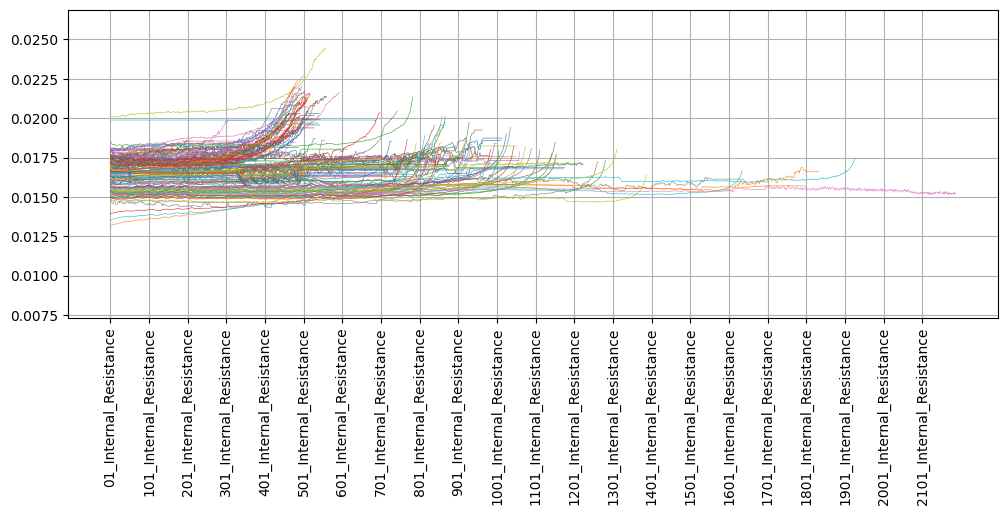

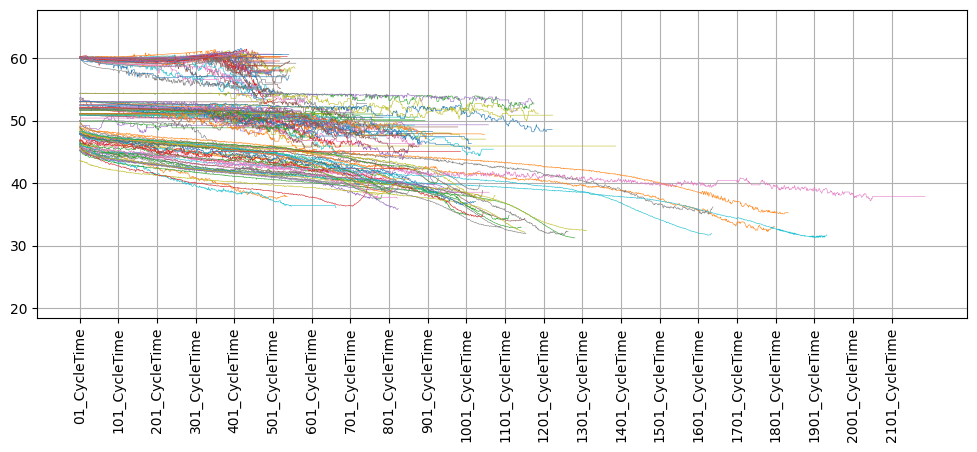

In [18]:
for i in range(4):
    plt.figure(figsize = (12,4))
    plt.plot(filtered_data_frames[i], linewidth = 0.4)
    plt.xticks(np.arange(0, filtered_data_frames[i].shape[0]+10,100), rotation = 90)
    y_max = filtered_data_frames[i].max().max()
    y_min = filtered_data_frames[i].min().min()
    plt.ylim(y_max*0.3, y_max*1.1)
    plt.grid()
    plt.show()

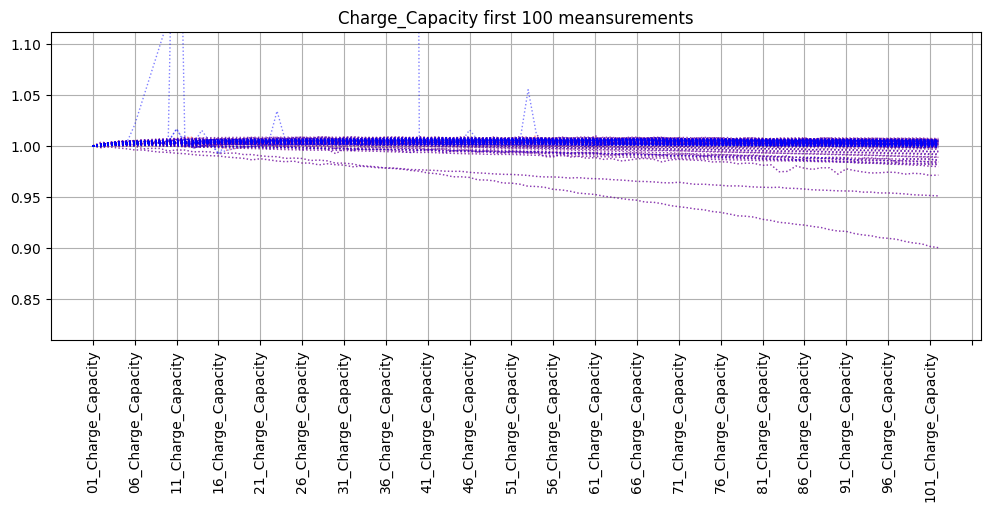

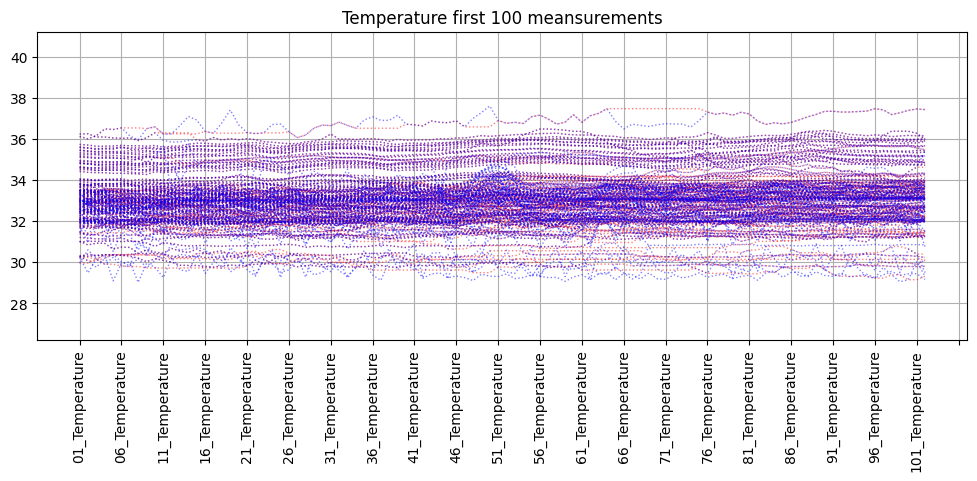

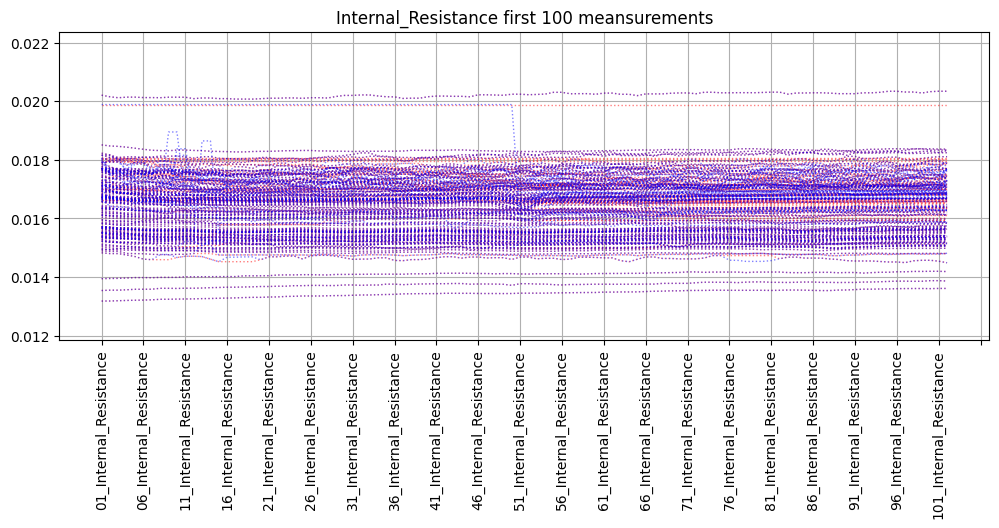

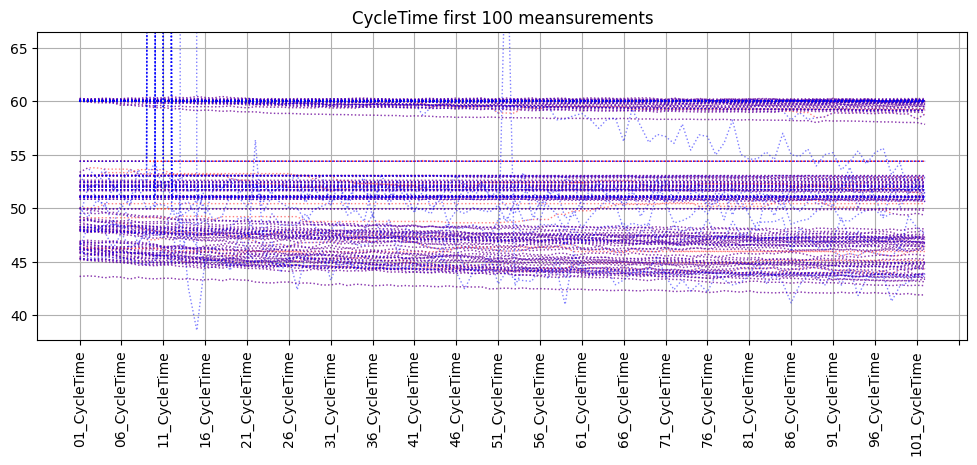

In [19]:
for i in range(4):
    plt.figure(figsize = (12,4))
    plt.title("_".join(filtered_data_frames[i].index[0].split('_')[1:]) + ' first 100 meansurements')
    plt.plot(filtered_data_frames[i].iloc[:102,:], linewidth = 1, linestyle = 'dotted', color = 'r', alpha = 0.5)
    plt.plot(data_frames[i].iloc[:102,:], linewidth = 1, linestyle = 'dotted', color = 'b', alpha = 0.5)
    plt.xticks(np.arange(0, filtered_data_frames[i].iloc[:102,:].shape[0]+5, 5), rotation = 90)
    y_max = filtered_data_frames[i].iloc[:102,:].max().max()
    y_min = filtered_data_frames[i].iloc[:102,:].min().min()
    plt.ylim(y_min - y_min/np.abs(y_min)*(np.abs(y_min)*0.1), 
             y_max*1.1)
    plt.grid()
    # plt.ylim(y_max*0.1, y_max*1.2)
    plt.show()

## 10. Save filtered feature DataFrames to disk

The filtered DataFrames are saved as compressed pickle files. These are the inputs to all modeling notebooks.

In [21]:
with gzip.open('data/filtered_data_frames_num.pckl', 'wb') as f:
    pickle.dump(filtered_data_frames, f)

In [22]:
len(filtered_data_frames)

5

In [23]:
filtered_data_frames[0]

,2017-06-30_4_4C-55per_6C_CH19,2018-04-12_batch8_CH38,2018-04-12_batch8_CH10,2017-05-12_7C-30per_3_6C_CH39,2017-06-30_3_6C-80per_3_6C_CH1,2017-06-30_4_4C-47per_5_5C_CH18,2018-04-12_batch8_CH11,2018-04-12_batch8_CH39,2017-05-12_8C-35per_3_6C_CH48,2017-06-30_4_8C-80per_4_8C_CH4,...,2018-04-12_batch8_CH34,2017-06-30_5_2C-66per_3_5C_CH35,2018-04-12_batch8_CH1,2018-04-12_batch8_CH20,2017-05-12_6C-40per_3C_CH25,2017-05-12_7C-40per_3_6C_CH41,2018-04-12_batch8_CH21,2018-04-12_batch8_CH35,2017-06-30_4_8C-80per_4_8C_CH8,2017-05-12_6C-40per_3_6C_CH34
01_Charge_Capacity,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
02_Charge_Capacity,0.999469,1.000355,1.000607,1.000993,0.999561,1.000822,1.001084,1.000842,1.001160,1.001077,...,1.000676,1.001631,0.998316,1.000718,1.000789,1.001021,1.000793,1.000817,1.002038,1.000945
03_Charge_Capacity,1.000710,1.000647,1.001124,1.001488,1.000024,1.001965,1.001746,1.001472,1.001798,1.001585,...,1.001647,1.002699,1.001499,1.001188,1.001469,1.001249,1.001366,1.001465,1.003053,1.001430
04_Charge_Capacity,1.001153,1.000878,1.001623,1.001663,1.000403,1.001601,1.002326,1.002019,1.002177,1.002998,...,1.002058,1.003495,1.001780,1.001666,1.001844,1.001563,1.001734,1.001803,1.003054,1.001770
05_Charge_Capacity,1.000947,1.000875,1.001856,1.001903,1.000303,1.002199,1.002544,1.002555,1.002502,1.002628,...,1.002594,1.003831,1.002124,1.001897,1.002313,1.001953,1.002036,1.002170,1.003826,1.001987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185_Charge_Capacity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2186_Charge_Capacity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2187_Charge_Capacity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2188_Charge_Capacity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
